In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports done")

All imports done


In [2]:
X_train     = joblib.load('../data/X_train.pkl')
X_train_res = joblib.load('../data/X_train_res.pkl')
y_train     = joblib.load('../data/y_train.pkl')
y_train_res = joblib.load('../data/y_train_res.pkl')
X_test      = joblib.load('../data/X_test.pkl')
y_test      = joblib.load('../data/y_test.pkl')

# Class weight ratio for XGBoost and LightGBM
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

print("=== DATA LOADED ===")
print(f"X_train original : {X_train.shape}")
print(f"X_train SMOTE    : {X_train_res.shape}")
print(f"X_test           : {X_test.shape}")
print(f"\nClass ratio (neg/pos): {scale_pos:.1f}")
print(f"This means for every 1 fraud there are {int(scale_pos)} legit transactions")

=== DATA LOADED ===
X_train original : (227845, 35)
X_train SMOTE    : (454902, 35)
X_test           : (56962, 35)

Class ratio (neg/pos): 577.3
This means for every 1 fraud there are 577 legit transactions


In [3]:
print("Training XGBoost... (takes 1-2 mins)")

xgb = XGBClassifier(
    n_estimators       = 300,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos,   # handles class imbalance
    eval_metric        = 'aucpr',     # optimize for PR-AUC
    early_stopping_rounds = 20,
    random_state       = 42,
    use_label_encoder  = False,
    verbosity          = 0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Training complete")
print(f"Best iteration: {xgb.best_iteration}")

Training XGBoost... (takes 1-2 mins)
Training complete
Best iteration: 52


In [4]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

roc_xgb   = roc_auc_score(y_test, y_prob_xgb)
prauc_xgb = average_precision_score(y_test, y_prob_xgb)

print("=== XGBOOST RESULTS ===\n")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC  : {roc_xgb:.4f}")
print(f"PR-AUC   : {prauc_xgb:.4f}")

=== XGBOOST RESULTS ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.39      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.69      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC  : 0.9768
PR-AUC   : 0.7167


In [5]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test, y_prob_xgb
)

target_recall = 0.85
valid_idx = np.where(recall_xgb[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_idx_xgb   = valid_idx[np.argmax(precision_xgb[:-1][valid_idx])]
    best_thresh_xgb = thresholds_xgb[best_idx_xgb]
else:
    best_thresh_xgb = 0.5

y_pred_xgb_opt = (y_prob_xgb >= best_thresh_xgb).astype(int)

print(f"=== XGBOOST OPTIMIZED THRESHOLD: {best_thresh_xgb:.4f} ===\n")
print(classification_report(y_test, y_pred_xgb_opt,
      target_names=['Legitimate', 'Fraud']))

roc_xgb_opt   = roc_auc_score(y_test, y_prob_xgb)
prauc_xgb_opt = average_precision_score(y_test, y_prob_xgb)
print(f"ROC-AUC : {roc_xgb_opt:.4f}")
print(f"PR-AUC  : {prauc_xgb_opt:.4f}")

=== XGBOOST OPTIMIZED THRESHOLD: 0.6212 ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.52      0.86      0.64        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9768
PR-AUC  : 0.7167


In [6]:
print("Training LightGBM... (takes 1-2 mins)")

lgbm = LGBMClassifier(
    n_estimators       = 1000,
    learning_rate      = 0.02,
    num_leaves         = 63,
    max_depth          = -1,
    min_child_samples  = 10,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = scale_pos,
    random_state       = 42,
    verbose            = -1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        __import__('lightgbm').early_stopping(50, verbose=False),
        __import__('lightgbm').log_evaluation(period=-1)
    ]
)

print(f"Training complete")
print(f"Best iteration: {lgbm.best_iteration_}")

Training LightGBM... (takes 1-2 mins)
Training complete
Best iteration: 404


In [7]:
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

roc_lgbm   = roc_auc_score(y_test, y_prob_lgbm)
prauc_lgbm = average_precision_score(y_test, y_prob_lgbm)

print("=== LIGHTGBM RESULTS ===\n")
print(classification_report(y_test, y_pred_lgbm,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC  : {roc_lgbm:.4f}")
print(f"PR-AUC   : {prauc_lgbm:.4f}")

=== LIGHTGBM RESULTS ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC  : 0.9597
PR-AUC   : 0.8336


In [8]:
precision_lgbm, recall_lgbm, thresholds_lgbm = precision_recall_curve(
    y_test, y_prob_lgbm
)

valid_idx_lgbm = np.where(recall_lgbm[:-1] >= target_recall)[0]

if len(valid_idx_lgbm) > 0:
    best_idx_lgbm    = valid_idx_lgbm[np.argmax(precision_lgbm[:-1][valid_idx_lgbm])]
    best_thresh_lgbm = thresholds_lgbm[best_idx_lgbm]
else:
    best_thresh_lgbm = 0.5

y_pred_lgbm_opt = (y_prob_lgbm >= best_thresh_lgbm).astype(int)

print(f"=== LIGHTGBM OPTIMIZED THRESHOLD: {best_thresh_lgbm:.4f} ===\n")
print(classification_report(y_test, y_pred_lgbm_opt,
      target_names=['Legitimate', 'Fraud']))

roc_lgbm_opt   = roc_auc_score(y_test, y_prob_lgbm)
prauc_lgbm_opt = average_precision_score(y_test, y_prob_lgbm)
print(f"ROC-AUC : {roc_lgbm_opt:.4f}")
print(f"PR-AUC  : {prauc_lgbm_opt:.4f}")

=== LIGHTGBM OPTIMIZED THRESHOLD: 0.0247 ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.46      0.86      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9597
PR-AUC  : 0.8336


In [9]:
baseline = joblib.load('../models/baseline_results.pkl')

print("=" * 60)
print(f"{'MODEL':<25} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("=" * 60)
print(f"{'Logistic Regression':<25} {baseline['roc_auc']:>10.4f} {baseline['pr_auc']:>10.4f}")
print(f"{'XGBoost':<25} {roc_xgb:>10.4f} {prauc_xgb:>10.4f}")
print(f"{'LightGBM':<25} {roc_lgbm:>10.4f} {prauc_lgbm:>10.4f}")
print("=" * 60)

winner = 'XGBoost' if prauc_xgb >= prauc_lgbm else 'LightGBM'
print(f"\nBest model by PR-AUC: {winner}")

MODEL                        ROC-AUC     PR-AUC
Logistic Regression           0.9736     0.7316
XGBoost                       0.9768     0.7167
LightGBM                      0.9597     0.8336

Best model by PR-AUC: LightGBM


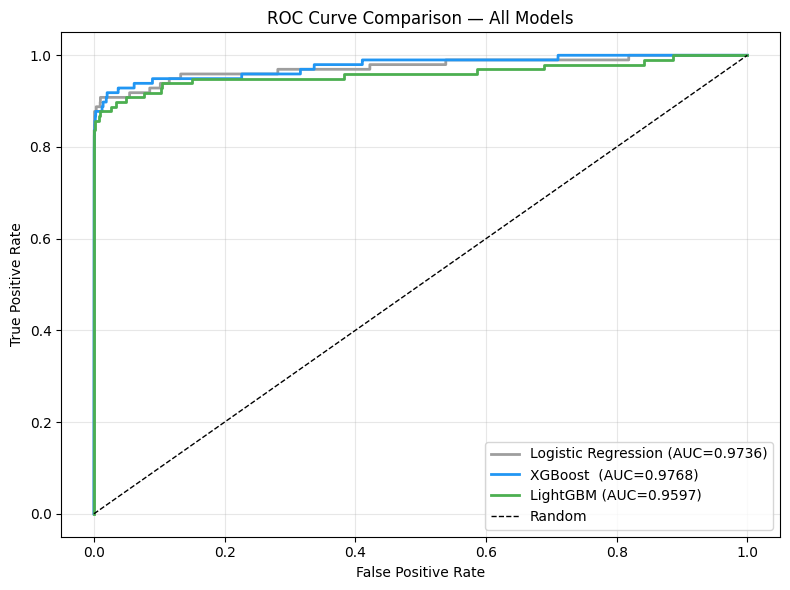

In [10]:
fpr_lr,   tpr_lr,   _ = roc_curve(y_test,
    joblib.load('../models/baseline_lr.pkl').predict_proba(X_test)[:, 1])
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, y_prob_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,   tpr_lr,   label=f'Logistic Regression (AUC={baseline["roc_auc"]:.4f})',
         color='#9E9E9E', linewidth=2)
plt.plot(fpr_xgb,  tpr_xgb,  label=f'XGBoost  (AUC={roc_xgb:.4f})',
         color='#2196F3', linewidth=2)
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={roc_lgbm:.4f})',
         color='#4CAF50', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/12_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

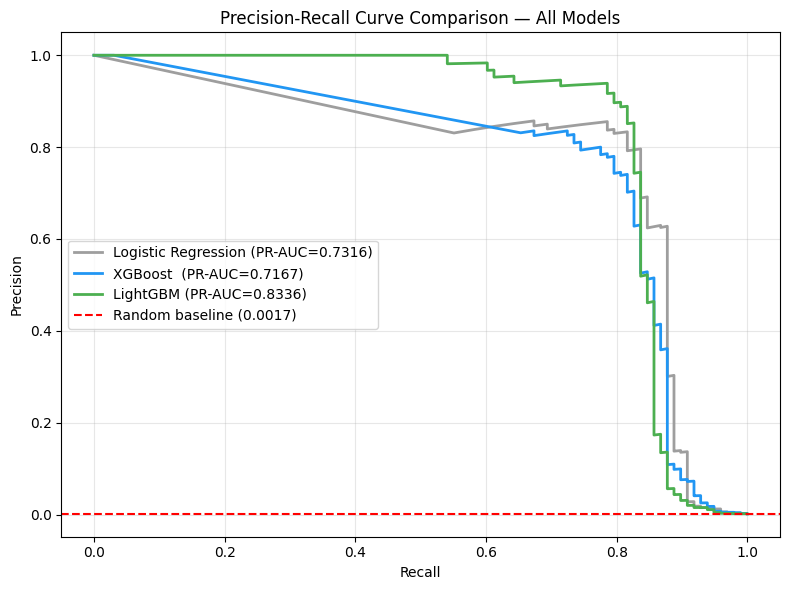

In [11]:
lr_probs = joblib.load('../models/baseline_lr.pkl').predict_proba(X_test)[:, 1]
p_lr, r_lr, _ = precision_recall_curve(y_test, lr_probs)

plt.figure(figsize=(8, 6))
plt.plot(r_lr,        p_lr,        label=f'Logistic Regression (PR-AUC={baseline["pr_auc"]:.4f})',
         color='#9E9E9E', linewidth=2)
plt.plot(recall_xgb,  precision_xgb,  label=f'XGBoost  (PR-AUC={prauc_xgb:.4f})',
         color='#2196F3', linewidth=2)
plt.plot(recall_lgbm, precision_lgbm, label=f'LightGBM (PR-AUC={prauc_lgbm:.4f})',
         color='#4CAF50', linewidth=2)
plt.axhline(y=y_test.mean(), color='red', linestyle='--',
            label=f'Random baseline ({y_test.mean():.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/13_pr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

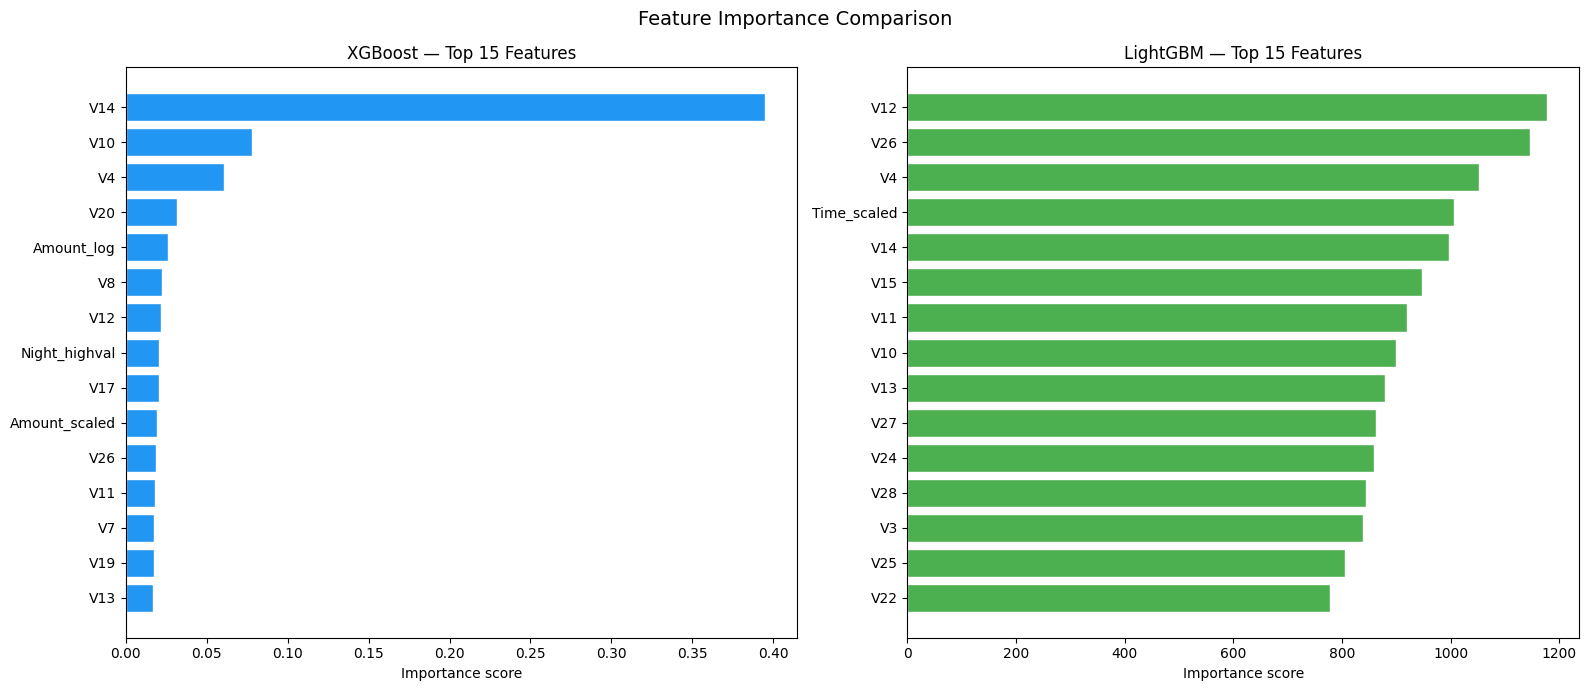

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost importance
xgb_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

axes[0].barh(xgb_imp.index, xgb_imp.values,
             color='#2196F3', edgecolor='white')
axes[0].set_title('XGBoost — Top 15 Features')
axes[0].set_xlabel('Importance score')
axes[0].invert_yaxis()

# LightGBM importance
lgbm_imp = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

axes[1].barh(lgbm_imp.index, lgbm_imp.values,
             color='#4CAF50', edgecolor='white')
axes[1].set_title('LightGBM — Top 15 Features')
axes[1].set_xlabel('Importance score')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../data/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Save models
joblib.dump(xgb,  '../models/xgb.pkl')
joblib.dump(lgbm, '../models/lgbm.pkl')

# Save thresholds
joblib.dump(best_thresh_xgb,  '../models/xgb_threshold.pkl')
joblib.dump(best_thresh_lgbm, '../models/lgbm_threshold.pkl')

# Save probabilities for ensemble in notebook 06
joblib.dump(y_prob_xgb,  '../data/y_prob_xgb.pkl')
joblib.dump(y_prob_lgbm, '../data/y_prob_lgbm.pkl')

# Save results dict
xgb_results = {
    'model'    : 'XGBoost',
    'roc_auc'  : round(roc_xgb, 4),
    'pr_auc'   : round(prauc_xgb, 4),
    'threshold': round(best_thresh_xgb, 4),
}
lgbm_results = {
    'model'    : 'LightGBM',
    'roc_auc'  : round(roc_lgbm, 4),
    'pr_auc'   : round(prauc_lgbm, 4),
    'threshold': round(best_thresh_lgbm, 4),
}

joblib.dump(xgb_results,  '../models/xgb_results.pkl')
joblib.dump(lgbm_results, '../models/lgbm_results.pkl')

print("=== ALL FILES SAVED ===")
print("models/xgb.pkl")
print("models/lgbm.pkl")
print("models/xgb_threshold.pkl")
print("models/lgbm_threshold.pkl")
print("data/y_prob_xgb.pkl")
print("data/y_prob_lgbm.pkl")

=== ALL FILES SAVED ===
models/xgb.pkl
models/lgbm.pkl
models/xgb_threshold.pkl
models/lgbm_threshold.pkl
data/y_prob_xgb.pkl
data/y_prob_lgbm.pkl


In [14]:
print("=" * 55)
print("       MODELS NOTEBOOK COMPLETE")
print("=" * 55)
print(f"""
RESULTS SUMMARY
  {'Model':<22} {'ROC-AUC':>8} {'PR-AUC':>8}
  {'-'*40}
  {'Logistic Regression':<22} {baseline['roc_auc']:>8.4f} {baseline['pr_auc']:>8.4f}
  {'XGBoost':<22} {roc_xgb:>8.4f} {prauc_xgb:>8.4f}
  {'LightGBM':<22} {roc_lgbm:>8.4f} {prauc_lgbm:>8.4f}

WINNER
  {winner} wins on PR-AUC

NEXT STEP
  → Open 05_optuna.ipynb
  → Tune the winner with 100 Optuna trials
  → Expected improvement: +2 to +4 PR-AUC points
""")
print("=" * 55)

       MODELS NOTEBOOK COMPLETE

RESULTS SUMMARY
  Model                   ROC-AUC   PR-AUC
  ----------------------------------------
  Logistic Regression      0.9736   0.7316
  XGBoost                  0.9768   0.7167
  LightGBM                 0.9597   0.8336

WINNER
  LightGBM wins on PR-AUC

NEXT STEP
  → Open 05_optuna.ipynb
  → Tune the winner with 100 Optuna trials
  → Expected improvement: +2 to +4 PR-AUC points

